In [1]:
import pandas, seaborn
import scipy, scipy.stats
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':12, 
                            'ytick.labelsize':8, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':16
                           })

In [2]:
# user-defined variables
expression_file = '/Users/adrian/research/bmcbf/029_orsay/results/000.quantification/results/DESeq2_TPM_values.tsv'
annotation_file = '/Users/adrian/software/kallisto/mouse_index_standard/annotation.tsv'

In [3]:
# read info
expression = pandas.read_csv(expression_file, sep='\t', index_col=0)
anno = pandas.read_csv(annotation_file, sep='\t')

expression.index = expression.index.str.split('.').str[0]

print(expression.shape)
expression.drop(['P9T001', 'P9T004', 'P9T009'], axis=1, inplace=True)
print(expression.shape)

(34183, 34)
(34183, 31)


In [4]:
# exclude additional ones bc after heatmap they are sparse
numbers = ["P9T011", "P9T015", "P9T033", "P9T013", "P9T014"]
print(expression.shape)
expression.drop(numbers, axis=1, inplace=True)
print(expression.shape)

(34183, 31)
(34183, 26)


In [5]:
input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_WT.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = list(sub.index)

input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_HOM.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = biomarkers + list(sub.index)[:30]
print(len(biomarkers))

input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_VGA.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = biomarkers + list(sub.index)[:30]
print(len(biomarkers), biomarkers)

(11, 12)
(100, 12)
41
(66, 12)
71 ['ENSMUSG00000034394', 'ENSMUSG00000026023', 'ENSMUSG00000030124', 'ENSMUSG00000095366', 'ENSMUSG00000050105', 'ENSMUSG00000096768', 'ENSMUSG00000024261', 'ENSMUSG00000050010', 'ENSMUSG00000092627', 'ENSMUSG00000056296', 'ENSMUSG00000033308', 'ENSMUSG00000040026', 'ENSMUSG00000052415', 'ENSMUSG00000056054', 'ENSMUSG00000056071', 'ENSMUSG00000040809', 'ENSMUSG00000056706', 'ENSMUSG00000061397', 'ENSMUSG00000051748', 'ENSMUSG00000027398', 'ENSMUSG00000031722', 'ENSMUSG00000023041', 'ENSMUSG00000059632', 'ENSMUSG00000026822', 'ENSMUSG00000068893', 'ENSMUSG00000029371', 'ENSMUSG00000063651', 'ENSMUSG00000054905', 'ENSMUSG00000026073', 'ENSMUSG00000039196', 'ENSMUSG00000059108', 'ENSMUSG00000030747', 'ENSMUSG00000040016', 'ENSMUSG00000024409', 'ENSMUSG00000071561', 'ENSMUSG00000051879', 'ENSMUSG00000025479', 'ENSMUSG00000019359', 'ENSMUSG00000026832', 'ENSMUSG00000054065', 'ENSMUSG00000030278', 'ENSMUSG00000029298', 'ENSMUSG00000073409', 'ENSMUSG00000079017

In [6]:
sub

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_name,biotype,description2,medianTPM_VGA,medianTPM_all
ENSMUSG00000029298,963.425901,-1.042892,0.126642,79.930870,3.877410e-19,4.421798e-15,ENSMUSG00000029298,Gbp9,protein_coding,guanylate-binding protein 9,14.518241,7.308962
ENSMUSG00000073409,460.420868,-2.184872,0.336232,59.166928,1.448479e-14,8.259226e-11,ENSMUSG00000073409,H2-Q6,protein_coding,"histocompatibility 2, Q region locus 6",23.085596,5.779719
ENSMUSG00000079017,1401.920049,-2.150868,0.365117,48.576793,3.176055e-12,1.207324e-08,ENSMUSG00000079017,Ifi27l2a,protein_coding,"interferon, alpha-inducible protein 27 like 2A",494.620385,114.371697
ENSMUSG00000029816,208.132057,-3.035028,0.564342,44.626466,2.384465e-11,6.798111e-08,ENSMUSG00000029816,Gpnmb,protein_coding,glycoprotein (transmembrane) nmb,3.107548,1.064141
ENSMUSG00000105504,218.596218,-1.149312,0.192056,42.504489,7.052019e-11,1.608425e-07,ENSMUSG00000105504,Gbp5,protein_coding,guanylate binding protein 5,5.170663,2.454644
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000040483,1162.543997,-1.058509,0.321136,12.950596,3.198196e-04,4.240956e-02,ENSMUSG00000040483,Xaf1,protein_coding,XIAP associated factor 1,99.042378,41.438418
ENSMUSG00000079055,165.611932,-1.137444,0.347862,12.823219,3.423442e-04,4.487464e-02,ENSMUSG00000079055,Slc8a3,protein_coding,solute carrier family 8 (sodium/calcium exchan...,2.708622,1.216706
ENSMUSG00000034295,256.117097,-1.396318,0.438124,12.740356,3.578497e-04,4.616833e-02,ENSMUSG00000034295,Fhod3,protein_coding,formin homology 2 domain containing 3,6.062421,2.424312
ENSMUSG00000023341,191.751767,-1.311813,0.412342,12.506293,4.055836e-04,4.973415e-02,ENSMUSG00000023341,Mx2,protein_coding,MX dynamin-like GTPase 2,10.883747,3.631400


In [7]:
df = expression.loc[biomarkers]
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T012,P9T016,P9T017,...,P9T024,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T034
ENSMUSG00000034394,21.876112,13.571332,42.489780,16.099713,40.681755,14.187001,9.246905,10.918618,10.204460,7.734754,...,7.928348,7.910788,8.530758,10.094681,14.476410,13.285303,15.558664,6.301973,8.062981,9.669246
ENSMUSG00000026023,8.297105,16.833076,12.031429,10.997231,10.411869,10.916543,8.776796,8.019623,9.658121,6.785156,...,6.420031,5.021607,5.935086,4.320336,6.983708,3.659295,3.987656,3.379811,5.983841,7.637204
ENSMUSG00000030124,13.411665,15.231313,22.740764,11.791541,19.025335,8.828053,8.474153,8.229261,5.630670,10.021325,...,5.260726,4.903183,8.401615,4.620849,3.922125,11.301971,8.231642,6.179308,7.541917,6.226719
ENSMUSG00000095366,58.010706,120.038664,52.464723,53.650888,59.290861,60.130795,41.204810,40.240697,28.652229,45.097033,...,29.079577,37.277714,17.973233,12.010788,16.941173,16.782182,34.389647,25.172342,51.484692,58.765472
ENSMUSG00000050105,39.335838,26.577148,38.665982,44.544169,31.412847,21.052179,23.449065,32.649012,9.986664,15.215930,...,11.697116,10.004530,16.694364,17.060956,12.326064,10.288205,15.191242,12.834090,21.519702,18.799414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000055413,5.796134,3.223065,5.174910,2.385777,2.694645,1.823323,1.504888,1.370503,1.494877,1.388583,...,1.703443,2.731159,4.543370,1.978199,6.606224,70.754342,2.809665,8.329885,16.076300,10.800698
ENSMUSG00000035692,26.976206,36.716982,22.919420,30.974035,23.383177,16.168407,17.300937,12.703225,25.114637,17.146767,...,22.836030,14.538188,35.828886,20.461790,38.847016,127.179683,20.350203,154.922439,146.507879,73.550338
ENSMUSG00000062488,6.849451,12.518723,7.859832,7.857618,6.544291,5.954789,6.680659,7.204134,7.776284,4.792174,...,4.825101,4.892701,6.883409,3.447941,9.511214,32.985573,3.730868,29.586540,31.546911,22.659015
ENSMUSG00000121166,0.325632,0.171796,0.792584,0.338661,0.224739,0.084973,0.553511,0.455982,0.343986,0.259208,...,0.577011,0.480027,1.450562,0.309054,1.107441,1.018518,0.501560,6.854959,0.312253,0.174585


In [8]:
label_map = dict(zip(anno['ensembl_gene_id'], anno['external_gene_name']))
df.rename(index=label_map, inplace=True)
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T012,P9T016,P9T017,...,P9T024,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T034
Lif,21.876112,13.571332,42.489780,16.099713,40.681755,14.187001,9.246905,10.918618,10.204460,7.734754,...,7.928348,7.910788,8.530758,10.094681,14.476410,13.285303,15.558664,6.301973,8.062981,9.669246
Cdk15,8.297105,16.833076,12.031429,10.997231,10.411869,10.916543,8.776796,8.019623,9.658121,6.785156,...,6.420031,5.021607,5.935086,4.320336,6.983708,3.659295,3.987656,3.379811,5.983841,7.637204
Lag3,13.411665,15.231313,22.740764,11.791541,19.025335,8.828053,8.474153,8.229261,5.630670,10.021325,...,5.260726,4.903183,8.401615,4.620849,3.922125,11.301971,8.231642,6.179308,7.541917,6.226719
G530011O06Riky,58.010706,120.038664,52.464723,53.650888,59.290861,60.130795,41.204810,40.240697,28.652229,45.097033,...,29.079577,37.277714,17.973233,12.010788,16.941173,16.782182,34.389647,25.172342,51.484692,58.765472
Fam110d,39.335838,26.577148,38.665982,44.544169,31.412847,21.052179,23.449065,32.649012,9.986664,15.215930,...,11.697116,10.004530,16.694364,17.060956,12.326064,10.288205,15.191242,12.834090,21.519702,18.799414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2-Q5,5.796134,3.223065,5.174910,2.385777,2.694645,1.823323,1.504888,1.370503,1.494877,1.388583,...,1.703443,2.731159,4.543370,1.978199,6.606224,70.754342,2.809665,8.329885,16.076300,10.800698
Isg15,26.976206,36.716982,22.919420,30.974035,23.383177,16.168407,17.300937,12.703225,25.114637,17.146767,...,22.836030,14.538188,35.828886,20.461790,38.847016,127.179683,20.350203,154.922439,146.507879,73.550338
Ifit3b,6.849451,12.518723,7.859832,7.857618,6.544291,5.954789,6.680659,7.204134,7.776284,4.792174,...,4.825101,4.892701,6.883409,3.447941,9.511214,32.985573,3.730868,29.586540,31.546911,22.659015
Gm57322,0.325632,0.171796,0.792584,0.338661,0.224739,0.084973,0.553511,0.455982,0.343986,0.259208,...,0.577011,0.480027,1.450562,0.309054,1.107441,1.018518,0.501560,6.854959,0.312253,0.174585


In [9]:
df_zscore = df.apply(scipy.stats.zscore, axis=1)
df_zscore

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T012,P9T016,P9T017,...,P9T024,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T034
Lif,0.924727,0.013366,3.186859,0.290829,2.988448,0.080929,-0.461194,-0.277742,-0.356113,-0.627137,...,-0.605892,-0.607819,-0.539784,-0.368160,0.112688,-0.018023,0.231454,-0.784370,-0.591118,-0.414847
Cdk15,0.346264,3.088592,1.545980,1.213726,1.025668,1.187803,0.500373,0.257118,0.783514,-0.139476,...,-0.256779,-0.706046,-0.412575,-0.931342,-0.075688,-1.143712,-1.038221,-1.233502,-0.396912,0.134259
Lag3,1.012733,1.413302,3.066398,0.656086,2.248501,0.003718,-0.074188,-0.128098,-0.700140,0.266399,...,-0.781577,-0.860285,-0.090156,-0.922437,-1.076251,0.548315,-0.127574,-0.579365,-0.279406,-0.568928
G530011O06Riky,0.875708,3.633262,0.629152,0.681885,0.932619,0.969960,0.128574,0.085713,-0.429472,0.301609,...,-0.410473,-0.046012,-0.904224,-1.169294,-0.950106,-0.957174,-0.174405,-0.584176,0.585583,0.909262
Fam110d,1.989199,0.705428,1.921798,2.513258,1.191993,0.149509,0.390683,1.316375,-0.963895,-0.437730,...,-0.791791,-0.962097,-0.288971,-0.252085,-0.728506,-0.933554,-0.440214,-0.677389,0.196551,-0.077162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2-Q5,-0.096175,-0.288911,-0.142708,-0.351629,-0.328493,-0.393760,-0.417612,-0.427678,-0.418362,-0.426324,...,-0.402739,-0.325758,-0.190013,-0.382159,-0.035494,4.769548,-0.319877,0.093617,0.673866,0.278694
Isg15,-0.401760,-0.181928,-0.493314,-0.311536,-0.482848,-0.645673,-0.620113,-0.723876,-0.443772,-0.623593,...,-0.495196,-0.682464,-0.201971,-0.548779,-0.133857,1.859654,-0.551297,2.485758,2.295857,0.649335
Ifit3b,-0.467874,0.117354,-0.363574,-0.363803,-0.499375,-0.560228,-0.485298,-0.431261,-0.372199,-0.680243,...,-0.676844,-0.669866,-0.464369,-0.819006,-0.193105,2.230108,-0.789799,1.879232,2.081597,1.164117
Gm57322,-0.367360,-0.487990,-0.001199,-0.357143,-0.446475,-0.556072,-0.188668,-0.265146,-0.352967,-0.419446,...,-0.170240,-0.246291,0.514754,-0.380359,0.245696,0.175967,-0.229406,4.752612,-0.377851,-0.485803


In [10]:
group_dict = {}

# Group A: P9T002 to P9T008 (excluding P9T004 and P9T009)
for i in range(1, 10):
    if i not in [1, 4, 9]:
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "WT"

# Group B: P9T010 to P9T015
for i in range(10, 19):
    if i not in [11, 15, 13, 14]: 
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "HET"

# Group C: P9T020 to P9T025
for i in range(19, 31):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HOM"

for i in range(31, 35):
    if i not in [33]:
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "VGA"

for element in group_dict.keys():
    print(element, group_dict[element])
    
group_series = pandas.Series(group_dict).reindex(df_zscore.columns)
group_colors = group_series.map({'WT': 'gray', 'HET': 'gold', 'HOM': 'tab:red', 'VGA': 'skyblue'})

P9T002 WT
P9T003 WT
P9T005 WT
P9T006 WT
P9T007 WT
P9T008 WT
P9T010 HET
P9T012 HET
P9T016 HET
P9T017 HET
P9T018 HET
P9T019 HOM
P9T020 HOM
P9T021 HOM
P9T022 HOM
P9T023 HOM
P9T024 HOM
P9T025 HOM
P9T026 HOM
P9T027 HOM
P9T028 HOM
P9T029 HOM
P9T030 HOM
P9T031 VGA
P9T032 VGA
P9T034 VGA


In [11]:
# exclude flat ones. count how many are postive, should be more than two
print(df_zscore.shape)
df_filtered = df_zscore[(df_zscore > 0).sum(axis=1) > 2]
print(df_filtered.shape)

(71, 26)
(65, 26)


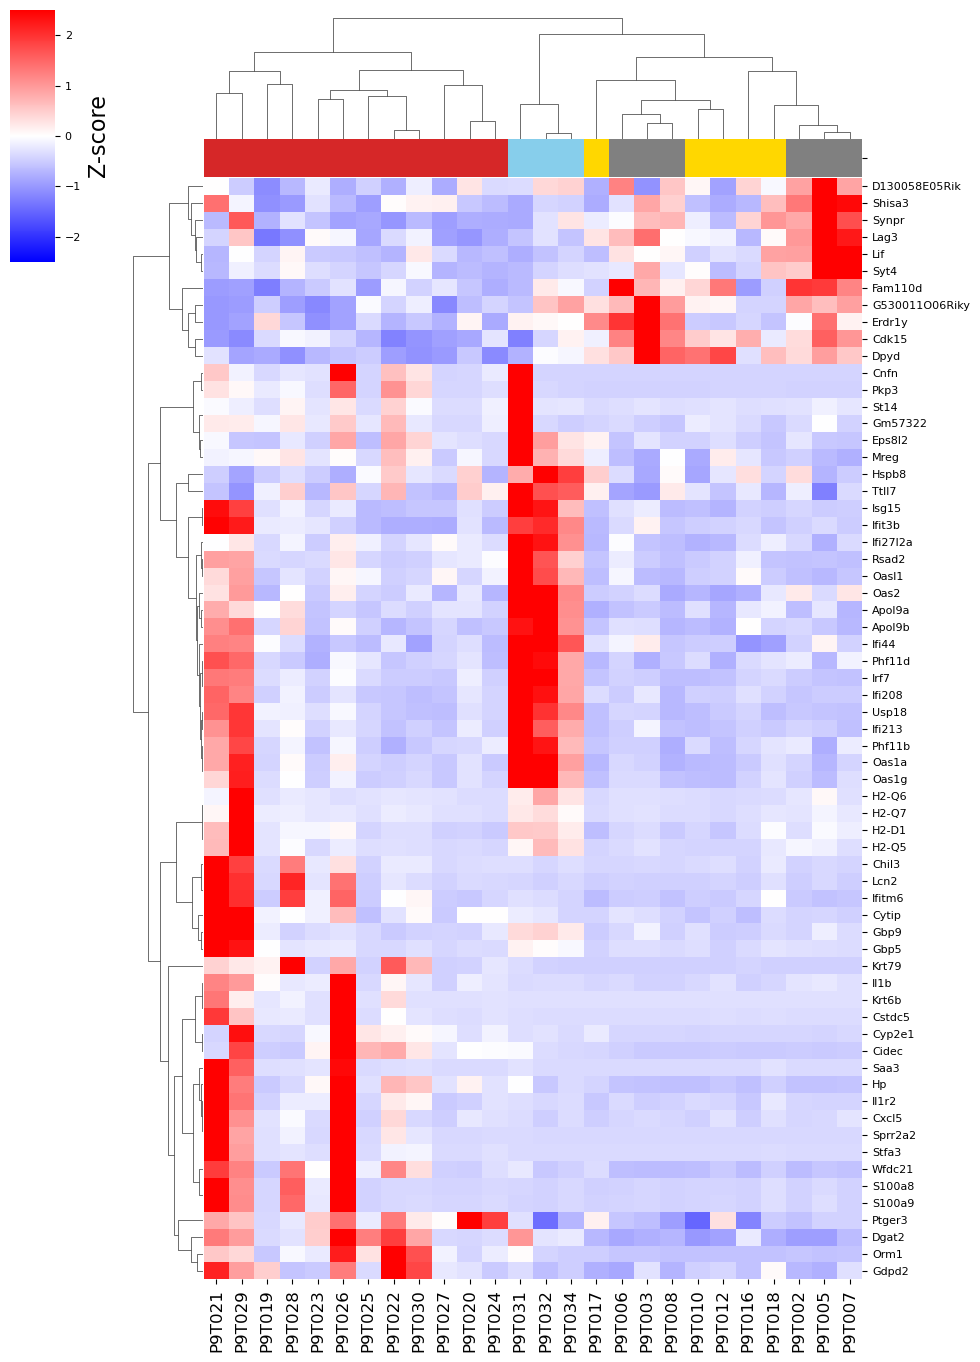

In [12]:
# euclidean ward seems to work fine
# correlation average also seems good
# correlation complete is the best with top 20
# cosine average good
g = seaborn.clustermap(
    df_filtered,
    metric='correlation',     # distance metric
    method='complete',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(9, 14),
    col_colors=group_colors,
    #row_colors=row_colors,
    dendrogram_ratio=(0.1, 0.1),  # adjust size of dendrograms
    cbar_pos=(-0.1, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)
